# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

As stated in the paper, the data collected for this study was collected over the course of 17 marketing campaigns for just over 2 years.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [40]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [41]:
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

In [42]:
df.isnull().sum() # No 'missing' data, but this dataset uses unkown istead of NaN, need another mwthod to see unkown value counts 

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [43]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    n_unknown = (df[col] == 'unknown').sum()
    if n_unknown > 0:
        pct = n_unknown / len(df) * 100
        print(f"{col}: {n_unknown} unknown ({pct:.1f}%)")

job: 330 unknown (0.8%)
marital: 80 unknown (0.2%)
education: 1731 unknown (4.2%)
default: 8597 unknown (20.9%)
housing: 990 unknown (2.4%)
loan: 990 unknown (2.4%)


In [44]:
df['pdays'].value_counts().head()

pdays
999    39673
3        439
6        412
4        118
9         64
Name: count, dtype: int64

In [45]:
df['y'].value_counts(normalize=True) # There are many more 'no' outputs than 'yes' 

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

No features need a data type change, since all numeric featurs are of type int or float, but I want to note that pdays uses 'not previously contacted' as 999


##### Data Visualization

To better understand the data before modeling, we visualize the target distribution, the age distribution by outcome, and how subscription rate varies across key categorical features

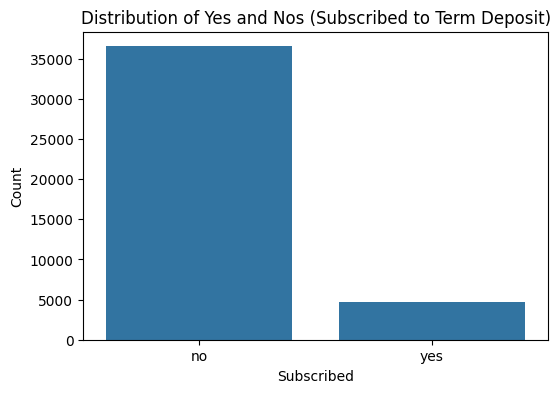

In [79]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='y', ax=ax)
ax.set_title('Distribution of Yes and Nos (Subscribed to Term Deposit)')
ax.set_xlabel('Subscribed')
ax.set_ylabel('Count')
plt.show()

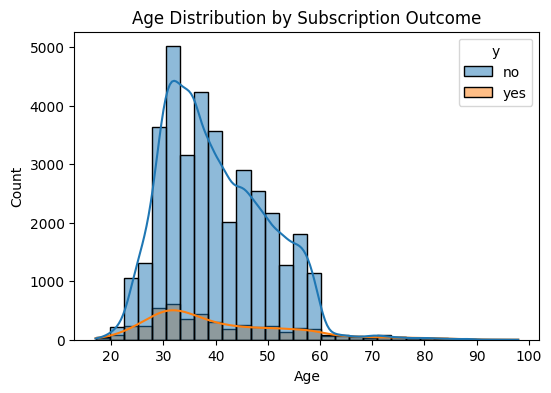

In [77]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df, x='age', hue='y', bins=30, kde=True, ax=ax)
ax.set_title('Age Distribution by Subscription Outcome')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
plt.show()

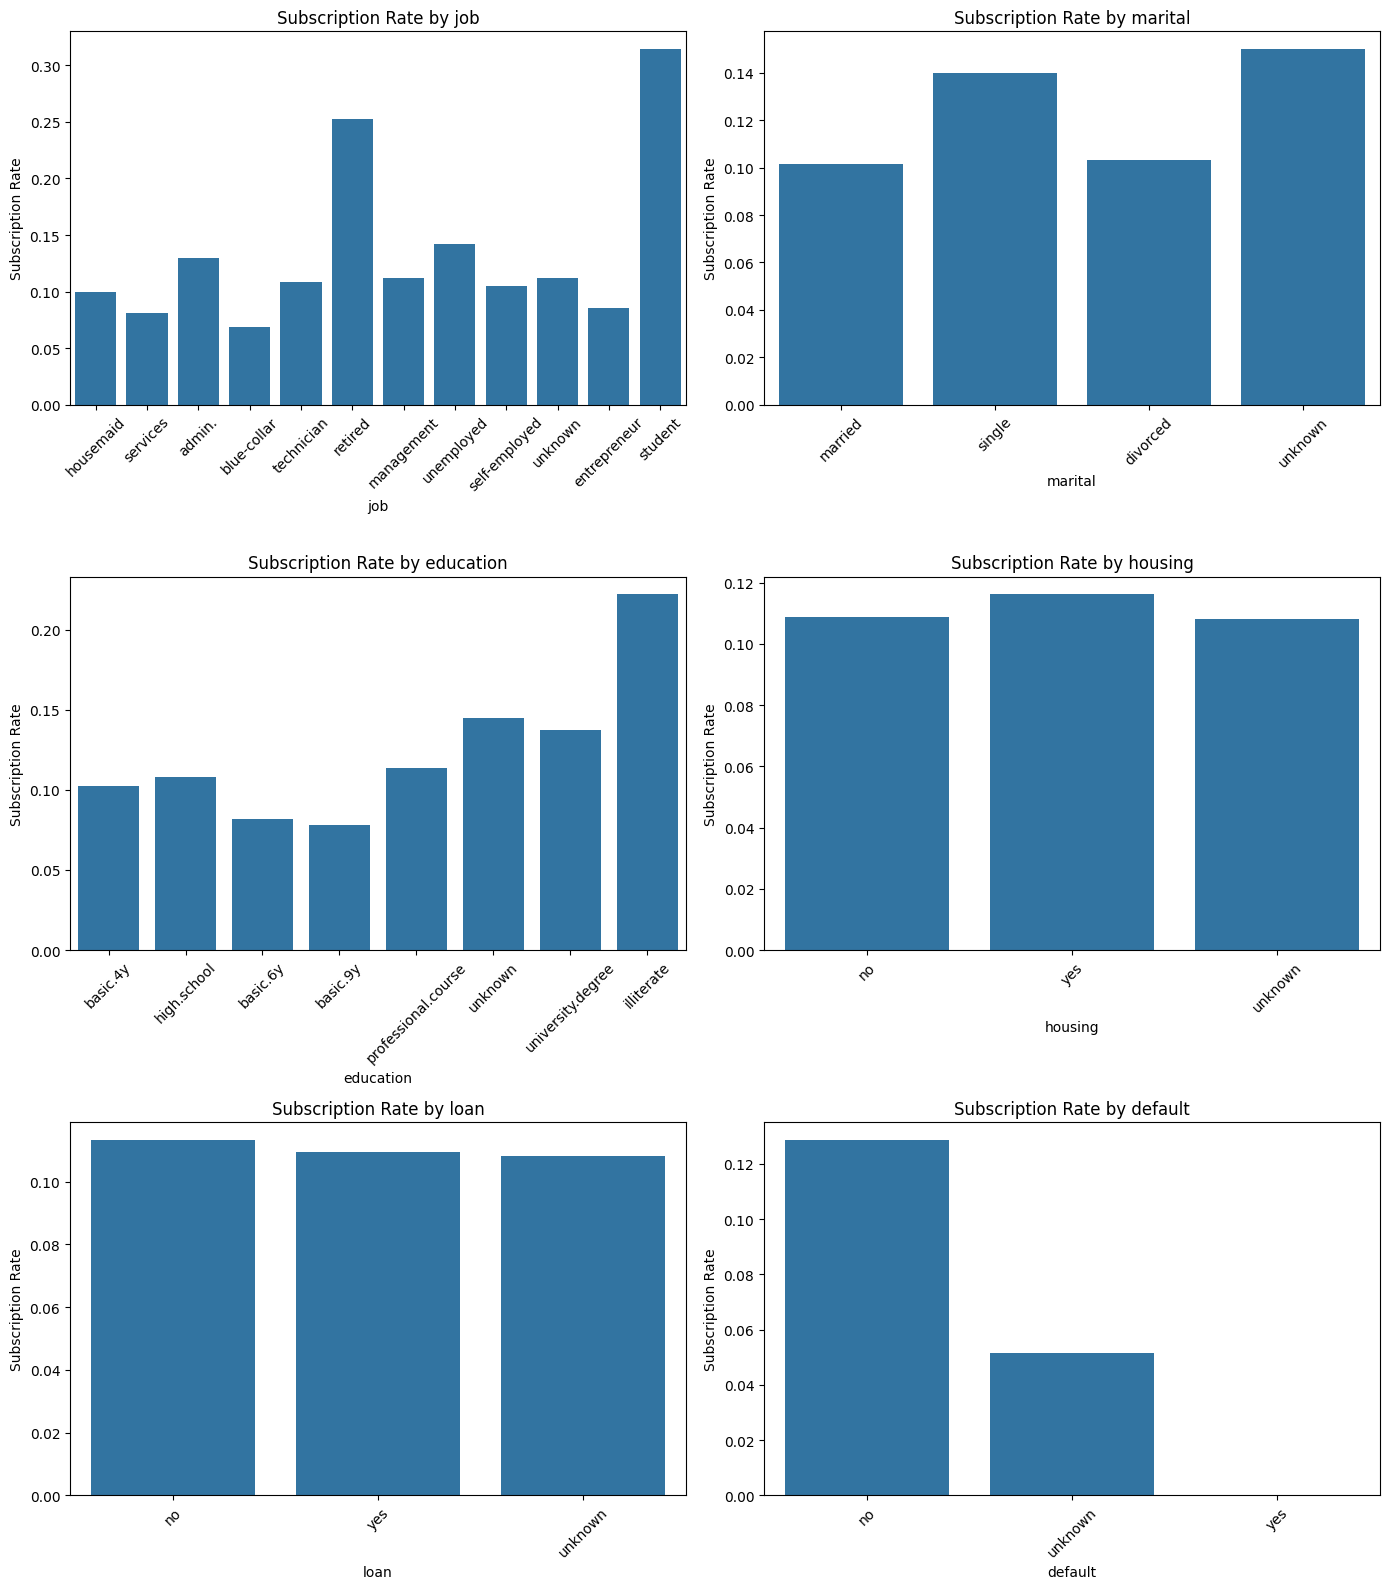

In [78]:
cat_cols_to_plot = ['job', 'marital', 'education', 'housing', 'loan', 'default']

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols_to_plot):
    sns.barplot(data=df, x=col, y=(df['y']=='yes').astype(int), ax=axes[i], errorbar=None)
    axes[i].set_title(f'Subscription Rate by {col}')
    axes[i].set_ylabel('Subscription Rate')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

##### Business Objective:
Build a classification model that predicts whether a client will subscribe to a term deposit based on their attributes and campaign contact history. This model should help the bank's marketing team prioritize which clients to contact, increasing the success rate of calls while reducing the number of unnecessary contacts, time, and cost associated with the telemarketing campaign."

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Using just the bank client data features only which is 1-7
bank_cols = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
X = df[bank_cols]
y = (df['y'] == 'yes').astype(int)  # 1 = subscribed, 0 = did not

In [48]:
num_feats = ['age']
cat_feats = ['job', 'marital', 'education', 'default', 'housing', 'loan']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_feats),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), cat_feats)
    ]
)

In [49]:
X.head()

,age,job,marital,education,default,housing,loan
0,56,housemaid,married,basic.4y,no,no,no
1,57,services,married,high.school,unknown,no,no
2,37,services,married,high.school,no,yes,no
3,40,admin.,married,basic.6y,no,no,no
4,56,services,married,high.school,no,no,yes


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [52]:
print(y_train.mean(), y_test.mean()) # proportion of yes and no's match for test and training set

0.112880774335567 0.11197436146450422


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [53]:
from sklearn.dummy import DummyClassifier

In [54]:
dummy = DummyClassifier(random_state=42)
dummy.fit(X_train, y_train)
baseline_acc = dummy.score(X_test, y_test)
print(f"Baseline accuracy: {baseline_acc:.4f}")

Baseline accuracy: 0.8880


Baseline accuracy is ~88.8% which matches the proportion of 'no's in the test set. Any real classifier needs to beat this to be considered useful

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [56]:
from sklearn.linear_model import LogisticRegression

logreg_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

logreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

### Problem 9: Score the Model

What is the accuracy of your model?

In [57]:
train_acc = logreg_pipe.score(X_train, y_train)
test_acc = logreg_pipe.score(X_test, y_test)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Train accuracy: 0.8871
Test accuracy: 0.8880


Test accuracy is exactly the same as the baseline

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [ ]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [61]:
# Logistic Regression
# Redoing this here for the timing data frame
start = time.time()
logreg_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])
logreg_pipe.fit(X_train, y_train)
logreg_time = time.time() - start

logreg_train_acc = logreg_pipe.score(X_train, y_train)
logreg_test_acc = logreg_pipe.score(X_test, y_test)

In [62]:
# KNN
start = time.time()
knn_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])
knn_pipe.fit(X_train, y_train)
knn_time = time.time() - start

knn_train_acc = knn_pipe.score(X_train, y_train)
knn_test_acc = knn_pipe.score(X_test, y_test)

In [63]:
# Decision Tree
start = time.time()
dt_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
dt_pipe.fit(X_train, y_train)
dt_time = time.time() - start

dt_train_acc = dt_pipe.score(X_train, y_train)
dt_test_acc = dt_pipe.score(X_test, y_test)

In [ ]:
# SVM
start = time.time()
svm_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])
svm_pipe.fit(X_train, y_train)
svm_time = time.time() - start

svm_train_acc = svm_pipe.score(X_train, y_train)
svm_test_acc = svm_pipe.score(X_test, y_test)

In [65]:
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM'],
    'Train Time': [logreg_time, knn_time, dt_time, svm_time],
    'Train Accuracy': [logreg_train_acc, knn_train_acc, dt_train_acc, svm_train_acc],
    'Test Accuracy': [logreg_test_acc, knn_test_acc, dt_test_acc, svm_test_acc]
})
results_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.416726,0.887119,0.888026
1,KNN,0.078145,0.889159,0.875789
2,Decision Tree,0.627816,0.916966,0.864718
3,SVM,60.925847,0.887443,0.888317


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [66]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# Log Reg parameter tuning
logreg_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear'],
    'classifier__class_weight': [None, 'balanced'] #added balanced weight due to poor performance without 
}

logreg_grid = GridSearchCV(
    Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(random_state=42, max_iter=1000))]),
    param_grid=logreg_param_grid,
    scoring='recall',
    cv=5
)
logreg_grid.fit(X_train, y_train)

print("Best params:", logreg_grid.best_params_)
print("Best CV recall:", logreg_grid.best_score_)

Best params: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV recall: 0.6983087567265358


In [68]:
# KNN tuning
knn_param_grid = {
    'classifier__n_neighbors': [5, 15, 30, 50],
    'classifier__weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    Pipeline(steps=[('preprocessor', preprocessor), ('classifier', KNeighborsClassifier())]),
    param_grid=knn_param_grid,
    scoring='recall',
    cv=5
)
knn_grid.fit(X_train, y_train)

print("Best params:", knn_grid.best_params_)
print("Best CV recall:", knn_grid.best_score_)

Best params: {'classifier__n_neighbors': 5, 'classifier__weights': 'distance'}
Best CV recall: 0.09922262007046163


In [ ]:
# Decision tre tuning
dt_param_grid = {
    'classifier__max_depth': [3, 5, 10, None],
    'classifier__min_samples_leaf': [1, 10, 50],
    'classifier__class_weight': [None, 'balanced'] #added balanced weight due to poor performance without
}

dt_grid = GridSearchCV(
    Pipeline(steps=[('preprocessor', preprocessor), ('classifier', DecisionTreeClassifier(random_state=42))]),
    param_grid=dt_param_grid,
    scoring='recall',
    cv=5
)
dt_grid.fit(X_train, y_train)

print("Best params:", dt_grid.best_params_)
print("Best CV recall:", dt_grid.best_score_)

Best params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 50}
Best CV recall: 0.9151085495348464


In [73]:
# SVM tuning
# Keeping paramtater grid here small due to computational complexity of SVM gridsearch CV
svm_param_grid = {
    'classifier__C': [0.1, 1],
    'classifier__class_weight': [None, 'balanced'] #added balanced weight due to poor performance without
}

svm_grid = GridSearchCV(
    Pipeline(steps=[('preprocessor', preprocessor), ('classifier', SVC(random_state=42))]),
    param_grid=svm_param_grid,
    scoring='recall',
    cv=3
)
svm_grid.fit(X_train, y_train)

print("Best params:", svm_grid.best_params_)
print("Best CV recall:", svm_grid.best_score_)

Best params: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}
Best CV recall: 0.629768058846367


In [74]:
# use tuned models on test set
from sklearn.metrics import recall_score, accuracy_score

tuned_models = {
    'Logistic Regression': logreg_grid.best_estimator_,
    'KNN': knn_grid.best_estimator_,
    'Decision Tree': dt_grid.best_estimator_,
    'SVM': svm_grid.best_estimator_
}

tuned_results = []
for name, model in tuned_models.items():
    preds = model.predict(X_test)
    tuned_results.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, preds),
        'Test Recall': recall_score(y_test, preds)
    })

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df

,Model,Test Accuracy,Test Recall
0,Logistic Regression,0.537341,0.684302
1,KNN,0.865203,0.089332
2,Decision Tree,0.298534,0.906331
3,SVM,0.615228,0.595837


#### Interpreting Model Coefficients

Since our tuned Logistic Regression model used L1 regularization, many feature
coefficients were shrunk to exactly zero which means the model determined those
categories carry no independent predictive signal beyond what's captured by
the other features. Below I extract and interpret the non-zero coefficients.

In [80]:
best_logreg = logreg_grid.best_estimator_
feature_names = best_logreg.named_steps['preprocessor'].get_feature_names_out()
coefs = best_logreg.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df = coef_df[coef_df['coefficient'] != 0].sort_values('coefficient', ascending=False)
coef_df

,feature,coefficient
9,cat__job_student,0.775044
6,cat__job_retired,0.574042
15,cat__marital_single,0.233474
23,cat__education_university.degree,0.148757
0,num__age,0.090560
1,cat__job_admin.,0.052656
20,cat__education_high.school,-0.009077
28,cat__housing_no,-0.011142
13,cat__marital_divorced,-0.013975
8,cat__job_services,-0.069865


The model found only a handful of features meaningfully predictive:

- **Being a student or retired are the strongest positive signals.** Students
  and retired individuals are considerably more likely to subscribe than the
  reference group. This makes intuitive sense: both groups may have more
  disposable time to consider financial products, and retirees in particular
  may be actively seeking safe, interest bearing savings vehicles like term
  deposits.
- **`default = unknown` is the strongest negative signal,** more negative than
  any single job or education category. Clients who declined to disclose
  their credit default status are notably less likely to subscribe. This
  may reflect general reluctance to engage with the bank's offers, or could
  correlate with clients the bank has less complete information about overall.
- **Being a blue-collar worker** is moderately associated with lower
  subscription likelihood.
- **Age has a small positive effect.** Older clients are slightly more
  likely to subscribe, consistent with the retiree finding above.
- Most job, education, and marital categories were zeroed out by L1
  regularization, meaning they add little predictive value once the stronger
  signals above are accounted for.

### Findings

Only about 11% of clients contacted actually subscribed to a term deposit,
so any useful model needs to beat just guessing "no" every time.

Basic client info (age, job, marital status, education, loan status) alone
was not enough to predict this well. Our first model performed no better
than the baseline. This suggests campaign details (how the client was
contacted, call length, timing) and economic conditions matter more than
who the client is on paper.

A few traits did stand out after tuning: students and retirees were more
likely to subscribe, while clients with unknown default status and
blue collar workers were less likely to.

We also found a tradeoff: pushing the model to catch more "yes" clients (switching performance metric to recall)
made it flag way more false leads. One tuned model caught 91% of actual
subscribers but was wrong about 70% of the time overall. This is a real
business tradeoff and it depends on how costly a wasted call
is versus a missed sale.

### Recommendations

1. Don't rely on demographics alone to target clients.
2. Add campaign and economic data (contact history, prior outcomes, interest
   rates) to future models, since the original research shows these matter more.
3. Consider prioritizing students and retirees as a quick, low cost win.
4. Decide how much a wasted call is worth vs. a missed client before tuning
   a model to prioritize recall.
5. Never use call duration to predict before a call happens. It's only
   known after the call ends.